# Supp Fig 5 — matches/exceeds tools (Visium & scRNA-seq)

Reproduces **SuppFig5** by inlining the actual generating code from the source notebooks/scripts. Set the paths in the config cell, then run top-to-bottom. Cost tags: 🟢 light · 🟡 moderate · 🔴 heavy.

## Configuration — edit the paths, then run

In [ ]:
import os, sys, glob, json, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Image
warnings.filterwarnings("ignore")
try:
    import scanpy as sc
    import anndata as ad
except Exception as e:
    print("[note] scanpy/anndata not available:", e)

# ── EDIT THESE PATHS to match your environment ──
REPO_ROOT     = Path("/path/to/spatnic")          # this repository
BACKUP_ROOT   = Path("/path/to/backup")           # integrate_adata_filtered.h5ad, galaxy scores, Liver meta
DATA_ROOT     = Path("/path/to/data")             # GxD concat, lung annotated, c2l refs, spatnic_models, GxD_Xenium
BENCHMARK_DB  = Path("/path/to/benchmark_db")     # Xenium/VisiumHD/MERFISH/CosMx + adata_hvg_*
VISIUMHD_ROOT = Path("/path/to/VisiumHD")         # Visium HD ADC track
WEIGHTS_DIR   = Path.home() / ".spatnic" / "weights"

# ── Derived ──
NB     = REPO_ROOT / "notebooks"
COMP   = NB / "comparison_results"
VHD    = VISIUMHD_ROOT
MODELS = DATA_ROOT / "spatnic_models"
PAPER  = REPO_ROOT / "paper"
BASE_DIR  = VHD          # VisiumHD ADC notebook global
THRESHOLD = 0.9          # overridden to 0.5 by the Fig 5 shortcut setup cell
sys.path[:0] = [str(REPO_ROOT / "scripts"), str(NB)]
if NB.exists():
    os.chdir(NB)         # extracted cells were written for cwd = notebooks/

def _tbl(csv, n=None):
    p = Path(csv)
    if not p.exists():
        print("[missing]", p); return None
    df = pd.read_parquet(p) if str(p).endswith(".parquet") else pd.read_csv(p)
    display(df.head(n) if n else df); return df

def _run(script, show=None, n=None):
    import subprocess
    cmd = f"python notebooks/{script}"
    print("$", cmd)
    r = subprocess.run(cmd, shell=True, cwd=str(REPO_ROOT), capture_output=True, text=True)
    print((r.stdout or "")[-3000:])
    if r.returncode: print("STDERR:\n", (r.stderr or "")[-2000:])
    if show: _tbl(COMP / show, n)


### SFig5a — setup (paths)
**🟢 light (reads caches)** · source: `compare_with_other_tools_visium.ipynb cell 2`

In [ ]:
from __future__ import annotations
import os, sys, json, shutil, subprocess, textwrap, gc
from pathlib import Path

import numpy as np
import pandas as pd
import anndata as ad

# === 入力 (apply_to_visium_v1v2.ipynb の出力) ===
POOLED_H5AD = (COMP / 'visium_v1v2_groundtruth/visium_epithelium_pooled.h5ad').resolve()
assert POOLED_H5AD.exists(), (
    f'{POOLED_H5AD} が見つかりません。先に apply_to_visium_v1v2.ipynb を実行してください。')

# === CRC primary scRNA-seq train データ (retrained 用; SPATNIC 学習データと同一) ===
BENCH_DIR  = BENCHMARK_DB
TRAIN_H5AD = BENCH_DIR / 'adata_hvg_train.h5ad'
GENE_LIST  = BENCH_DIR / 'adata_hvg_genes.txt'

LABEL_COL  = 'Raw_annotation'   # Tumor / Normal
SAMPLE_COL = 'sample'

# === 出力 ===
OUT_DIR  = (COMP / 'visium_tool_comparison').resolve()
WORK_DIR = OUT_DIR / 'work'
for d in (OUT_DIR, WORK_DIR):
    d.mkdir(parents=True, exist_ok=True)

# === 外部ツール ===
CANCERFINDER_DIR = Path.home() / 'SequencingCancerFinder'
ENVS = {'scmalignant': 'scmalignant', 'ikarus': 'scmalignant', 'cancerfinder': 'scf'}
CONDA_BIN = shutil.which('conda') or str(Path.home() / 'miniconda3/bin/conda')

# Jupyter カーネルが注入する MPLBACKEND / PYTHONPATH を切る
SUBPROC_ENV = {**os.environ, 'MPLBACKEND': 'Agg', 'PYTHONNOUSERSITE': '1'}
SUBPROC_ENV.pop('PYTHONPATH', None)

print('POOLED_H5AD =', POOLED_H5AD)
print('OUT_DIR     =', OUT_DIR)
print('TRAIN_H5AD  =', TRAIN_H5AD, '- exists:', TRAIN_H5AD.exists())

### SFig5a — helpers (per_sample_metrics/save_metrics)
**🟢 light (reads caches)** · source: `compare_with_other_tools_visium.ipynb cell 3`

In [ ]:
# === 共通ヘルパー ===
def run_in_env(env, script, cwd=WORK_DIR):
    """指定 conda env で `python -c <script>` を実行。"""
    cwd.mkdir(parents=True, exist_ok=True)
    return subprocess.run(
        [CONDA_BIN, 'run', '-n', env, '--no-capture-output', 'python', '-c', script],
        cwd=str(cwd), check=False, text=True, env=SUBPROC_ENV,
    )


def per_sample_metrics(df, y_true_col='y_true', y_pred_col='y_pred',
                       sample_col='sample', score_col=None,
                       positive='Tumor', negative='Normal'):
    """検体ごとの混同行列 + 指標。

    score_col (Tumor 連続スコア) を渡すと **AUC-PR / AUROC** も計算する。
    片クラス検体は AUC-PR / AUROC と片側 recall が NaN になる。
    """
    from sklearn.metrics import average_precision_score, roc_auc_score
    valid = df[y_true_col].isin([positive, negative]) & df[y_pred_col].isin([positive, negative])
    use_score = score_col is not None and score_col in df.columns
    cols = [sample_col, y_true_col, y_pred_col] + ([score_col] if use_score else [])
    sub = df.loc[valid, cols].copy()

    def _one(g):
        yt, yp = g[y_true_col].values, g[y_pred_col].values
        tp = int(((yt == positive) & (yp == positive)).sum())
        tn = int(((yt == negative) & (yp == negative)).sum())
        fp = int(((yt == negative) & (yp == positive)).sum())
        fn = int(((yt == positive) & (yp == negative)).sum())
        n  = tp + tn + fp + fn
        acc  = (tp + tn) / n if n > 0 else np.nan
        sens = tp / (tp + fn) if (tp + fn) > 0 else np.nan      # Tumor recall
        spec = tn / (tn + fp) if (tn + fp) > 0 else np.nan      # Normal recall
        prec = tp / (tp + fp) if (tp + fp) > 0 else np.nan
        f1   = (2 * tp / (2 * tp + fp + fn)) if (2 * tp + fp + fn) > 0 else np.nan
        bacc = np.nanmean([sens, spec])
        d = dict(n_cells=n, TP=tp, TN=tn, FP=fp, FN=fn,
                 accuracy=acc, balanced_accuracy=bacc,
                 sensitivity=sens, specificity=spec, precision=prec, f1=f1)
        if use_score:
            sv = pd.to_numeric(g[score_col], errors='coerce').values
            mk = np.isfinite(sv)
            ybin = (yt[mk] == positive).astype(int)
            if mk.sum() >= 5 and len(np.unique(ybin)) == 2:
                d['aucpr'] = float(average_precision_score(ybin, sv[mk]))
                d['auroc'] = float(roc_auc_score(ybin, sv[mk]))
            else:
                d['aucpr'] = np.nan
                d['auroc'] = np.nan
        return pd.Series(d)

    by_sample = sub.groupby(sample_col, sort=True).apply(_one, include_groups=False)
    overall   = _one(sub)
    return pd.concat([by_sample, pd.DataFrame([overall], index=['__OVERALL__'])], axis=0)


def save_metrics(df_metrics, out_csv):
    out_csv.parent.mkdir(parents=True, exist_ok=True)
    pretty = df_metrics.copy()
    for c in ['accuracy', 'balanced_accuracy', 'sensitivity', 'specificity',
              'precision', 'f1', 'aucpr', 'auroc']:
        if c in pretty.columns:
            pretty[c] = pretty[c].round(4)
    pretty.to_csv(out_csv)
    print(f'[saved] {out_csv}')
    return pretty

### SFig5a — SPATNIC predict -> SPATNIC.csv
**🔴 heavy (GPU / multi-GB / long)** · source: `compare_with_other_tools_visium.ipynb cell 6`

In [ ]:
import scanpy as sc
import spatnic
from spatnic import predict as spatnic_predict
print('spatnic version:', spatnic.__version__)

adata = ad.read_h5ad(POOLED_H5AD)
print('pooled:', adata.shape,
      '| Tumor/Normal =', dict(adata.obs[LABEL_COL].value_counts()),
      '| samples =', adata.obs[SAMPLE_COL].nunique())

# log-normalize (raw counts -> log1p)
if float(adata.X.max()) > 25:
    sc.pp.normalize_total(adata)
    sc.pp.log1p(adata)

adata = spatnic_predict(adata, model='tumor_normal')
df = pd.DataFrame({
    'sample': adata.obs[SAMPLE_COL].astype(str).values,
    'y_true': adata.obs[LABEL_COL].astype(str).values,
    'y_pred': adata.obs['spatnic_pred'].astype(str).values,
    'score':  pd.to_numeric(adata.obs['spatnic_score'], errors='coerce').values,
})
save_metrics(per_sample_metrics(df, score_col='score'), OUT_DIR / 'SPATNIC.csv')
del adata; gc.collect()

### SFig5a — scMalignantFinder pretrain download
**🔴 heavy (GPU / multi-GB / long)** · source: `compare_with_other_tools_visium.ipynb cell 8`

In [ ]:
# scMalignantFinder 公式 pretrain (Zenodo) をダウンロード
import urllib.request
PRETRAIN_DIR = Path.home() / '.scmalignant_pretrain'
PRETRAIN_DIR.mkdir(parents=True, exist_ok=True)
_ZENODO = {
    'model.joblib':        'https://zenodo.org/records/17888140/files/model.joblib?download=1',
    'ordered_feature.tsv': 'https://zenodo.org/records/17888140/files/ordered_feature.tsv?download=1',
}
for name, url in _ZENODO.items():
    dst = PRETRAIN_DIR / name
    if not dst.exists():
        print(f'[download] {url} -> {dst}')
        urllib.request.urlretrieve(url, str(dst))
print('PRETRAIN_DIR =', PRETRAIN_DIR)

### SFig5a — scMalignantFinder run -> scMalignant_*.csv
**🔴 heavy (GPU / multi-GB / long)** · source: `compare_with_other_tools_visium.ipynb cell 9`

In [ ]:
SCMF_TEMPLATE = textwrap.dedent("""
    import pandas as pd
    from scMalignantFinder import classifier
    model = classifier.scMalignantFinder(
        test_input={test!r},
        pretrain_dir={pretrain_dir!r},
        train_h5ad_path={train!r},
        feature_path={gene_list!r},
        model_method="LogisticRegression",
        norm_type=True, n_thread=8,
    )
    model.load()
    result_adata = model.predict()
    obs = result_adata.obs.copy()
    pred = obs["scMalignantFinder_prediction"].astype(str)
    pred = pred.replace({{"Malignant": "Tumor", "Non-malignant": "Normal",
                          "Non-Malignant": "Normal", "non-malignant": "Normal"}})
    obs["scMalignantFinder_prediction"] = pred
    cols = [{sample_col!r}, {label_col!r}, "scMalignantFinder_prediction"]
    if "malignancy_probability" in obs.columns:
        cols.append("malignancy_probability")
    obs[cols].to_csv({out_csv!r})
    print("[done]", {out_csv!r})
""")


def run_scmalignant(variant, pretrain_dir):
    out_obs = WORK_DIR / f'scMalignant_{variant}_obs.csv'
    script = SCMF_TEMPLATE.format(
        test=str(POOLED_H5AD), pretrain_dir=pretrain_dir, train=str(TRAIN_H5AD),
        gene_list=str(GENE_LIST), sample_col=SAMPLE_COL, label_col=LABEL_COL,
        out_csv=str(out_obs),
    )
    print(f'>>> scMalignantFinder ({variant})')
    r = run_in_env(ENVS['scmalignant'], script)
    if r.returncode != 0 or not out_obs.exists():
        print(f'[FAILED] scMalignantFinder ({variant}) rc={r.returncode}')
        return
    df = pd.read_csv(out_obs, index_col=0).rename(
        columns={LABEL_COL: 'y_true', 'scMalignantFinder_prediction': 'y_pred',
                 'malignancy_probability': 'score', SAMPLE_COL: 'sample'})
    sc_col = 'score' if 'score' in df.columns else None
    save_metrics(per_sample_metrics(df, score_col=sc_col),
                 OUT_DIR / f'scMalignant_{variant}.csv')


run_scmalignant('default',   pretrain_dir=str(PRETRAIN_DIR))
run_scmalignant('retrained', pretrain_dir=None)

### SFig5a — ikarus run -> ikarus_*.csv
**🔴 heavy (GPU / multi-GB / long)** · source: `compare_with_other_tools_visium.ipynb cell 11`

In [ ]:
# ikarus 公式 assets を作業ディレクトリへ
IKARUS_DIR = WORK_DIR / 'ikarus_assets'
IKARUS_DIR.mkdir(exist_ok=True)
for src in [BACKUP_ROOT / 'signatures.gmt',
            BACKUP_ROOT / 'core_model.joblib']:
    dst = IKARUS_DIR / src.name
    if src.exists() and not dst.exists():
        shutil.copy(src, dst)
    print(f'  {dst}  exists={dst.exists()}')

IKARUS_TEMPLATE = textwrap.dedent(r"""
    import glob
    from pathlib import Path
    import numpy as np
    import pandas as pd
    import anndata as ad
    from ikarus import classifier

    out_dir = Path({out_dir!r}); out_dir.mkdir(parents=True, exist_ok=True)

    adata = ad.read_h5ad({test!r})
    adata.obs_names_make_unique()
    adata.var["gene_symbol"] = adata.var_names.astype(str)
    adata.uns["log1p"] = {{"base": None}}
    X = adata.X.toarray() if hasattr(adata.X, "toarray") else np.asarray(adata.X)
    X = np.asarray(X, dtype=float); X[~np.isfinite(X)] = 0.0; adata.X = X
    # raw counts -> log1p (ikarus は log-normalized 入力を仮定し内部で expm1 する)
    import scanpy as sc
    if float(np.nanmax(adata.X)) > 25:
        sc.pp.normalize_total(adata)
        sc.pp.log1p(adata)
    keep_set = set(g.upper() for g in adata.var_names)

    train_adata = None
    if {variant_is_retrained}:
        train_adata = ad.read_h5ad({train!r})
        train_adata.obs_names_make_unique()
        train_adata.var["gene_symbol"] = train_adata.var_names.astype(str)
        train_adata.uns["log1p"] = {{"base": None}}
        Xt = train_adata.X.toarray() if hasattr(train_adata.X, "toarray") else np.asarray(train_adata.X)
        Xt = np.asarray(Xt, dtype=float); Xt[~np.isfinite(Xt)] = 0.0; train_adata.X = Xt
        if float(np.nanmax(train_adata.X)) > 25:
            sc.pp.normalize_total(train_adata)
            sc.pp.log1p(train_adata)
        keep_set = keep_set & set(g.upper() for g in train_adata.var_names)

    sig_filt = out_dir / "signatures_filtered.gmt"
    with open({sig!r}) as f, open(sig_filt, "w") as g:
        for line in f:
            parts = line.strip().split("\t")
            if len(parts) < 3:
                continue
            keep = sorted(set(x.upper() for x in parts[2:]) & keep_set)
            if keep:
                g.write(parts[0] + "\tna\t" + "\t".join(keep) + "\n")

    model = classifier.Ikarus(signatures_gmt=str(sig_filt), out_dir=str(out_dir))
    if train_adata is not None:
        model.fit([train_adata], ["train"], [{label_col_train!r}], save=True)
    else:
        model.load_core_model({core_model!r})

    N_SPLIT = {n_split}
    for i, idx in enumerate(np.array_split(np.arange(adata.n_obs), N_SPLIT)):
        model.predict(adata[idx, :].copy(), f"{tag}_chunk{{i+1:02d}}", save=True)

    files = sorted(glob.glob(str(out_dir / f"{tag}_chunk*/prediction.csv")))
    res = pd.concat([pd.read_csv(p, index_col=0) for p in files], axis=0, ignore_index=True)
    assert len(res) == adata.n_obs
    res.index = adata.obs.index
    res[{sample_col!r}] = adata.obs[{sample_col!r}].astype(str).values
    res[{label_col!r}] = adata.obs[{label_col!r}].astype(str).values
    res.to_csv({out_csv!r})
    print("[done]", {out_csv!r})
""")


def run_ikarus(variant, n_split=10):
    tag = f'ikarus_{variant}'
    chunk_root = WORK_DIR / f'{tag}_out'
    chunk_root.mkdir(parents=True, exist_ok=True)
    out_obs = WORK_DIR / f'{tag}_obs.csv'
    script = IKARUS_TEMPLATE.format(
        out_dir=str(chunk_root), sig=str(IKARUS_DIR / 'signatures.gmt'),
        core_model=str(IKARUS_DIR / 'core_model.joblib'),
        test=str(POOLED_H5AD), train=str(TRAIN_H5AD),
        variant_is_retrained=(variant == 'retrained'), label_col_train=LABEL_COL,
        n_split=n_split, tag=tag, sample_col=SAMPLE_COL, label_col=LABEL_COL,
        out_csv=str(out_obs),
    )
    print(f'>>> ikarus ({variant})')
    r = run_in_env(ENVS['ikarus'], script, cwd=chunk_root)
    if r.returncode != 0 or not out_obs.exists():
        print(f'[FAILED] ikarus ({variant}) rc={r.returncode}')
        return
    df = pd.read_csv(out_obs, index_col=0).rename(
        columns={LABEL_COL: 'y_true', 'core_pred': 'y_pred', SAMPLE_COL: 'sample'})
    if 'core_pred_proba_Tumor' in df.columns:
        df = df.rename(columns={'core_pred_proba_Tumor': 'score'})
    sc_col = 'score' if 'score' in df.columns else None
    save_metrics(per_sample_metrics(df, score_col=sc_col),
                 OUT_DIR / f'ikarus_{variant}.csv')


run_ikarus('default',   n_split=10)
run_ikarus('retrained', n_split=10)

### SFig5a — Cancer-Finder run -> CancerFinder_*.csv
**🔴 heavy (GPU / multi-GB / long)** · source: `compare_with_other_tools_visium.ipynb cell 13`

In [ ]:
CF_DEFAULT_CKP = CANCERFINDER_DIR / 'checkpoints' / 'st_pretrain_article.pkl'

# CRC primary notebook で学習済みの retrained ckp を探す
CF_RETRAINED_CKP = None
primary_run = (COMP / 'work/cancerfinder/retrained_run').resolve()
if primary_run.exists():
    cands = sorted(primary_run.glob('**/*.pkl'))
    if cands:
        CF_RETRAINED_CKP = cands[-1]
print('CF default ckp   =', CF_DEFAULT_CKP, '(exists =', CF_DEFAULT_CKP.exists(), ')')
print('CF retrained ckp =', CF_RETRAINED_CKP)


def run_cancerfinder(variant, ckp):
    if ckp is None or not Path(ckp).exists():
        print(f'[skip] CancerFinder ({variant}): ckp なし')
        return
    out_csv = WORK_DIR / f'cancerfinder_{variant}_label.csv'
    cmd = [CONDA_BIN, 'run', '-n', ENVS['cancerfinder'], '--no-capture-output',
           'python', '-u', 'infer.py',
           f'--ckp={ckp}', f'--matrix={POOLED_H5AD}', f'--out={out_csv}']
    print(f'>>> Cancer-Finder ({variant})')
    r = subprocess.run(cmd, cwd=str(CANCERFINDER_DIR), env=SUBPROC_ENV)
    if r.returncode != 0 or not out_csv.exists():
        print(f'[FAILED] CancerFinder ({variant}) rc={r.returncode}')
        return
    # infer.py 出力: index 名 "sample" は実体 cell_id。'predict'=0/1, 'proba'=P(Tumor)
    raw = pd.read_csv(out_csv, index_col='sample')
    pred = raw[['predict'] + (['proba'] if 'proba' in raw.columns else [])].copy()
    pred.index.name = 'cell_id'
    pred['y_pred'] = pred['predict'].replace({1: 'Tumor', 0: 'Normal'})
    if 'proba' in pred.columns:
        pred = pred.rename(columns={'proba': 'score'})
    a = ad.read_h5ad(POOLED_H5AD, backed='r')
    truth = a.obs[[SAMPLE_COL, LABEL_COL]].astype(str).copy()
    truth.index.name = 'cell_id'
    truth = truth[~truth.index.duplicated(keep='first')]
    df = pred.join(truth, how='inner').rename(
        columns={LABEL_COL: 'y_true', SAMPLE_COL: 'sample'}).reset_index(drop=True)
    sc_col = 'score' if 'score' in df.columns else None
    save_metrics(per_sample_metrics(df, score_col=sc_col),
                 OUT_DIR / f'CancerFinder_{variant}.csv')


run_cancerfinder('default',   CF_DEFAULT_CKP)
run_cancerfinder('retrained', CF_RETRAINED_CKP)

### SFig5a — load per-tool CSVs -> df_all
**🟢 light (reads caches)** · source: `compare_with_other_tools_visium.ipynb cell 15`

In [ ]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
from matplotlib.ticker import MultipleLocator
from scipy.stats import wilcoxon

mpl.rcParams.update({
    'font.family':'sans-serif','font.sans-serif':['Arial','Helvetica','DejaVu Sans'],
    'font.size':7,'axes.titlesize':8,'axes.labelsize':7,
    'xtick.labelsize':6.5,'ytick.labelsize':6.5,
    'axes.spines.top':False,'axes.spines.right':False,
    'axes.linewidth':0.6,'xtick.major.width':0.6,'ytick.major.width':0.6,
    'xtick.major.size':2.5,'ytick.major.size':2.5,
    'pdf.fonttype':42,'ps.fonttype':42,'savefig.dpi':600,'savefig.bbox':'tight',
})

PALETTE = {
    'SPATNIC':                 '#0072B2',
    'scMalignant_retrained':   '#E69F00',
    'Cancer-Finder_retrained': '#009E73',
    'ikarus_retrained':        '#D55E00',
    'scMalignant_default':     '#BDBDBD',
    'Cancer-Finder_default':   '#8C8C8C',
    'ikarus_default':          '#525252',
}
DISPLAY = {
    'SPATNIC':                 'SPATNIC',
    'scMalignant_retrained':   'scMalignant (retrained)',
    'Cancer-Finder_retrained': 'Cancer-Finder (retrained)',
    'ikarus_retrained':        'ikarus (retrained)',
    'scMalignant_default':     'scMalignant (default)',
    'Cancer-Finder_default':   'Cancer-Finder (default)',
    'ikarus_default':          'ikarus (default)',
}
FILES = {
    'SPATNIC':                 OUT_DIR / 'SPATNIC.csv',
    'scMalignant_retrained':   OUT_DIR / 'scMalignant_retrained.csv',
    'Cancer-Finder_retrained': OUT_DIR / 'CancerFinder_retrained.csv',
    'ikarus_retrained':        OUT_DIR / 'ikarus_retrained.csv',
    'scMalignant_default':     OUT_DIR / 'scMalignant_default.csv',
    'Cancer-Finder_default':   OUT_DIR / 'CancerFinder_default.csv',
    'ikarus_default':          OUT_DIR / 'ikarus_default.csv',
}

dfs = []
for name, path in FILES.items():
    if not path.exists():
        print(f'[skip] {name}: {path} なし')
        continue
    d = pd.read_csv(path)
    if 'Unnamed: 0' in d.columns:
        d = d.rename(columns={'Unnamed: 0': 'sample'})
    d = d[d['sample'] != '__OVERALL__'].copy()
    d['model'] = name
    dfs.append(d)
df_all = pd.concat(dfs, ignore_index=True)
model_order = [m for m in FILES if m in set(df_all['model'])]
print('models:', model_order)
df_all.head()

### SFig5a — pairwise Wilcoxon + Bonferroni -> stats_long
**🟢 light (reads caches)** · source: `compare_with_other_tools_visium.ipynb cell 16`

In [ ]:
# === SPATNIC vs 各ツール: paired Wilcoxon + Bonferroni ===
base = 'SPATNIC'
others = [m for m in model_order if m != base]

def stars(p):
    if np.isnan(p): return 'n.a.'
    if p <= 1e-4:   return '****'
    if p <= 1e-3:   return '***'
    if p <= 1e-2:   return '**'
    if p <= 5e-2:   return '*'
    return 'n.s.'

def pairwise_pvals(metric):
    base_v = df_all[df_all['model'] == base][['sample', metric]].set_index('sample')
    raw, rows = [], []
    for m in others:
        sub = df_all[df_all['model'] == m][['sample', metric]].set_index('sample')
        merged = base_v.join(sub, lsuffix='_a', rsuffix='_b').dropna()
        if len(merged) < 5 or (merged[f'{metric}_a'] == merged[f'{metric}_b']).all():
            p = np.nan
        else:
            try:
                _, p = wilcoxon(merged[f'{metric}_a'], merged[f'{metric}_b'], zero_method='wilcox')
            except Exception:
                p = np.nan
        raw.append(p); rows.append((m, len(merged), p))
    k = int(np.sum(~np.isnan(raw)))
    adj = [min(p * k, 1.0) if not np.isnan(p) else np.nan for p in raw]
    return pd.DataFrame([{'metric': metric, 'vs': m, 'n_samples': n, 'p_raw': pr, 'p_bonf': pb}
                         for (m, n, pr), pb in zip(rows, adj)])

metric_titles = {'accuracy': 'Accuracy', 'balanced_accuracy': 'Balanced accuracy',
                 'sensitivity': 'Sensitivity', 'specificity': 'Specificity',
                 'precision': 'Precision', 'f1': 'F1 score',
                 'aucpr': 'AUC-PR', 'auroc': 'AUROC'}
# df_all に存在する指標のみ対象 (aucpr はスコア対応後に出現)
metrics_to_plot = [m for m in ['aucpr', 'sensitivity', 'specificity', 'balanced_accuracy',
                               'accuracy', 'precision', 'f1']
                   if m in df_all.columns]
stats_long = pd.concat([pairwise_pvals(m) for m in metrics_to_plot], ignore_index=True)
stats_long.to_csv(OUT_DIR / 'pairwise_vs_SPATNIC.csv', index=False)
stats_long

### Supp Fig 5a — Visium tool comparison
**🟢 light (reads caches)** · source: `compare_with_other_tools_visium.ipynb cell 18`

In [ ]:
# === boxplot + paired slopegraph ===
def draw_panel(ax, df_all, model_order, palette, tick_lbl, stats, metric, base):
    sns.boxplot(data=df_all, x='model', y=metric, order=model_order,
                palette=palette, ax=ax, fliersize=0, linewidth=0.5,
                width=0.55, boxprops={'alpha':0.55},
                medianprops={'color':'0.10','linewidth':0.8},
                whiskerprops={'linewidth':0.5}, capprops={'linewidth':0.5})
    pivot = (df_all[df_all['model'].isin(model_order)]
             .pivot(index='sample', columns='model', values=metric)
             .reindex(columns=model_order))
    xs = np.arange(len(model_order))
    for _, r in pivot.iterrows():
        ax.plot(xs, r.values, color='0.55', lw=0.25, alpha=0.30, zorder=2)
    for j, m in enumerate(model_order):
        ax.scatter(np.full_like(pivot[m].values, j, dtype=float), pivot[m].values,
                   s=6, color=palette[m], linewidths=0, alpha=0.95, zorder=3)
    ax.set_xlabel(''); ax.set_ylabel(metric_titles[metric]); ax.set_title(metric_titles[metric], pad=4)
    ax.set_xticks(xs); ax.set_xticklabels(tick_lbl, rotation=30, ha='right', rotation_mode='anchor')
    ax.yaxis.set_major_locator(MultipleLocator(0.25)); ax.yaxis.set_minor_locator(MultipleLocator(0.05))
    ax.tick_params(which='minor', length=1.2)
    # bracket
    base_idx = model_order.index(base)
    sub = stats[stats['metric']==metric].set_index('vs')
    brks = []
    for m in model_order:
        if m == base or m not in sub.index: continue
        p = sub.loc[m, 'p_bonf']
        if np.isnan(p): continue
        brks.append((abs(model_order.index(m)-base_idx), model_order.index(m), p))
    brks.sort(key=lambda x: x[0])
    y_max = float(np.nanmax(pivot.values)) if np.isfinite(pivot.values).any() else 1.0
    y_max = max(0.5, min(1.0, y_max))
    y0, step, bh = y_max+0.05, 0.085, 0.014
    for i,(_, tgt, p) in enumerate(brks):
        y = y0 + step*i
        ax.plot([base_idx, base_idx, tgt, tgt],[y-bh,y,y,y-bh], lw=0.45, c='0.35', clip_on=False, zorder=4)
        ax.text((base_idx+tgt)/2, y+0.006, stars(p), ha='center', va='bottom',
                fontsize=7, color='0.15', clip_on=False, zorder=5)
    top = y0 + step*max(0, len(brks)-1) + 0.08
    ax.set_ylim(-0.02, max(1.05, top))

palette_v  = {m: PALETTE[m] for m in model_order}
tick_lbl_v = [DISPLAY[m] for m in model_order]

# 個別 figure
for metric in metrics_to_plot:
    fig, ax = plt.subplots(figsize=(3.6, 3.0))
    draw_panel(ax, df_all, model_order, palette_v, tick_lbl_v, stats_long, metric, base)
    for ext in ('png','pdf'):
        fig.savefig(OUT_DIR / f'fig_compare_{metric}.{ext}')
    plt.show()

# 統合 grid (balanced_accuracy / sensitivity / specificity)
grid_metrics = ['balanced_accuracy', 'sensitivity', 'specificity']
fig, axes = plt.subplots(1, 3, figsize=(8.4, 3.0), constrained_layout=True)
for ax, m in zip(axes, grid_metrics):
    draw_panel(ax, df_all, model_order, palette_v, tick_lbl_v, stats_long, m, base)
for ext in ('png','pdf'):
    fig.savefig(OUT_DIR / f'fig_compare_grid.{ext}')
plt.show()

### Supp Fig 5a — overall bar plot
**🟢 light (reads caches)** · source: `compare_with_other_tools_visium.ipynb cell 21`

In [ ]:
# === overall bar plot — fig2b_benchmark.ipynb スタイル ===
#   * metric ごとに 1 panel (= 軸枠で囲まれた subplot)。AUC-PR / Sensitivity / Specificity を横並び
#   * 各 panel 内に method×variant の 7 本グループ縦棒、sharey で y 軸共有
#   * color は method 単位、retrained は斜線ハッチ、default は単色塗り、バー順 SPATNIC→retrained→default
#   * per-sample 平均 ± SEM + Wilcoxon (paired, Bonferroni) vs SPATNIC、bracket は枠外 (clip_on=False)
from matplotlib.patches import Patch

METHOD_PALETTE = {
    'SPATNIC':       '#D55E00',
    'Cancer-Finder': '#0072B2',
    'scMalignant':   '#009E73',
    'ikarus':        '#CC79A7',
}
BAR_FACE = {
    'SPATNIC':                 METHOD_PALETTE['SPATNIC'],
    'Cancer-Finder_default':   METHOD_PALETTE['Cancer-Finder'],
    'Cancer-Finder_retrained': METHOD_PALETTE['Cancer-Finder'],
    'scMalignant_default':     METHOD_PALETTE['scMalignant'],
    'scMalignant_retrained':   METHOD_PALETTE['scMalignant'],
    'ikarus_default':          METHOD_PALETTE['ikarus'],
    'ikarus_retrained':        METHOD_PALETTE['ikarus'],
}
BAR_HATCH = {
    'SPATNIC':                 '',
    'Cancer-Finder_default':   '',
    'Cancer-Finder_retrained': '//',
    'scMalignant_default':     '',
    'scMalignant_retrained':   '//',
    'ikarus_default':          '',
    'ikarus_retrained':        '//',
}
BAR_ORDER = [
    'SPATNIC',
    'Cancer-Finder_retrained', 'scMalignant_retrained', 'ikarus_retrained',
    'Cancer-Finder_default',   'scMalignant_default',   'ikarus_default',
]
GAP, STEP, BRACKET_H = 0.04, 0.075, 0.015

bar_metrics = [m for m in ['aucpr', 'sensitivity', 'specificity'] if m in df_all.columns]
keys = [k for k in BAR_ORDER if k in set(df_all['model'])]

mean = df_all.groupby('model')[bar_metrics].mean().reindex(keys)
sem  = df_all.groupby('model')[bar_metrics].sem().reindex(keys)
p_adj = stats_long.pivot(index='vs', columns='metric', values='p_bonf')


def draw_metric_panel(ax, metric, *, keys, mean, sem, p_adj, base='SPATNIC'):
    """1 metric = 1 panel。x=0 を中心に method×variant の 7 本グループ縦棒。"""
    n = len(keys)
    bar_w = 0.85 / n
    for i, k in enumerate(keys):
        offset = (i - (n - 1) / 2) * bar_w
        h = float(mean.loc[k, metric])
        e = sem.loc[k, metric]
        e = 0.0 if pd.isna(e) else float(e)
        hatch = BAR_HATCH.get(k, '')
        ec = 'black' if hatch else 'none'
        ax.bar(offset, h, width=bar_w, color=BAR_FACE[k], hatch=hatch,
               edgecolor=ec, linewidth=0.0,
               yerr=e, error_kw=dict(elinewidth=1.0, capsize=3.0, ecolor='0.25'))

    # SPATNIC vs 各ツールの有意差 bracket (枠の外 = ylim 1.0 より上)
    if base in keys and metric in p_adj.columns:
        base_off = (keys.index(base) - (n - 1) / 2) * bar_w
        heights = []
        for k in keys:
            h, e = mean.loc[k, metric], sem.loc[k, metric]
            if pd.isna(h):
                continue
            heights.append(h + (0 if pd.isna(e) else float(e)))
        y0 = max((max(heights) if heights else 0.0) + GAP, 1.0 + GAP)
        brks = []
        for i, k in enumerate(keys):
            if k == base or k not in p_adj.index:
                continue
            pv = p_adj.loc[k, metric]
            if pd.isna(pv):
                continue
            off = (i - (n - 1) / 2) * bar_w
            brks.append((abs(off - base_off), off, pv))
        brks.sort(key=lambda t: t[0])
        for idx, (_, off, pv) in enumerate(brks):
            y = y0 + STEP * idx
            ax.plot([base_off, base_off, off, off],
                    [y - BRACKET_H, y, y, y - BRACKET_H],
                    lw=1.6, c='0.10', clip_on=False, zorder=4, solid_capstyle='round')
            ax.text((base_off + off) / 2, y + 0.006, stars(pv),
                    ha='center', va='bottom', fontsize=16, fontweight='bold',
                    color='0.05', clip_on=False, zorder=5)

    half = n * bar_w / 2 + 0.06
    ax.set_xlim(-half, half)
    ax.set_xticks([])
    ax.set_ylim(0, 1.0)
    ax.yaxis.set_major_locator(MultipleLocator(0.25))
    ax.yaxis.set_minor_locator(MultipleLocator(0.05))
    ax.tick_params(which='minor', length=1.8)


if not bar_metrics:
    print('no metric available — run §1-4 + §5 first')
else:
    with mpl.rc_context({
        'font.size': 18, 'axes.titlesize': 22, 'axes.titleweight': 'bold',
        'axes.labelsize': 20, 'xtick.labelsize': 18, 'ytick.labelsize': 18,
        'axes.linewidth': 1.4, 'xtick.major.width': 1.4, 'ytick.major.width': 1.4,
        'xtick.major.size': 4.5, 'ytick.major.size': 4.5, 'hatch.linewidth': 1.0,
        # 各 panel を 4 辺の枠線で囲む (top/right spine も表示)
        'axes.spines.top': True, 'axes.spines.right': True,
    }):
        fig, axes = plt.subplots(1, len(bar_metrics),
                                 figsize=(4.6 * len(bar_metrics) + 0.6, 8.6),
                                 sharey=True, constrained_layout=True)
        if len(bar_metrics) == 1:
            axes = [axes]
        for ax, metric in zip(axes, bar_metrics):
            draw_metric_panel(ax, metric, keys=keys, mean=mean, sem=sem, p_adj=p_adj)
            # M = その指標が non-NaN な検体数 (AUC-PR は両クラス検体, 感度/特異度は該当クラスを持つ検体)
            m_count = int(df_all.loc[df_all[metric].notna(), 'sample'].nunique())
            ax.set_xlabel(f'{metric_titles.get(metric, metric)}  (M={m_count})',
                          fontsize=22, fontweight='bold', labelpad=14)
        axes[0].set_ylabel('Score', fontsize=20)

        n_samples = df_all['sample'].nunique()
        fig.suptitle(f'SPATNIC vs existing tools — Visium V1/V2 (CRC)  (N={n_samples})',
                     fontsize=20, fontweight='bold')
        legend_handles = [
            Patch(facecolor=BAR_FACE[k], hatch=BAR_HATCH.get(k, ''),
                  edgecolor='black' if BAR_HATCH.get(k, '') else 'none',
                  linewidth=0, label=DISPLAY[k])
            for k in keys
        ]
        fig.legend(handles=legend_handles, loc='center left', bbox_to_anchor=(1.0, 0.5),
                   frameon=False, fontsize=18, title='Method', title_fontsize=20)
        for ext in ('png', 'pdf'):
            fig.savefig(OUT_DIR / f'fig_overall_bar.{ext}', bbox_inches='tight')
            print(f'[saved] {OUT_DIR / f"fig_overall_bar.{ext}"}')
        plt.show()

### SFig5b — setup (paths)
**🟢 light (reads caches)** · source: `benchmark_scrnaseq.ipynb cell 2`

In [ ]:
from __future__ import annotations
import os, sys, json, shutil, subprocess, textwrap, gc
from pathlib import Path

import numpy as np
import pandas as pd

# === 入力データ（絶対パス） ===
BENCH_DIR  = BENCHMARK_DB
TRAIN_H5AD = BENCH_DIR / 'adata_hvg_train.h5ad'          # retrained 用 CRC 学習データ
GENE_LIST  = BENCH_DIR / 'adata_hvg_genes.txt'           # 3000 HVG リスト

# Cancer cell line: 5.4GB CPM テキスト + 付随メタデータ h5ad
CCL_TXT    = BENCH_DIR / 'GSE157220_CPM_data.txt'        # gene x cell（CPM）
CCL_META   = BENCH_DIR / 'test_cancerCellLine.h5ad'      # obs（Cell_line / Cancer_type）

# Normal epithelial: Tabula Sapiens Large Intestine（参照ノートで作成済み）
NORMAL_H5AD = BACKUP_ROOT / 'Normal_Large_Intestine.h5ad'

# Visium V1/V2 (CRC, 病理医 GT): apply_to_visium_v1v2.ipynb の pooled 出力（Tumor/Normal 両方）
VISIUM_POOLED = (COMP / 'visium_v1v2_groundtruth/visium_epithelium_pooled.h5ad').resolve()

# === 出力（絶対パスに resolve — subprocess の cwd 切替で相対パスが壊れないように） ===
OUT_DIR   = (COMP.resolve() / 'scrnaseq')
WORK_DIR  = OUT_DIR / 'work'
BENCH_OUT = OUT_DIR / 'datasets'                          # 整形済みベンチ h5ad の保存先
for d in [OUT_DIR, WORK_DIR, BENCH_OUT,
          OUT_DIR / 'cancerCellLine', OUT_DIR / 'normalEpithelial', OUT_DIR / 'visium']:
    d.mkdir(parents=True, exist_ok=True)

CCL_BENCH  = BENCH_OUT / 'bench_cancerCellLine.h5ad'
# NOTE: ファイル名は bench_normalEpi.h5ad（旧 bench_normalEpithelial.h5ad は
# WSL /mnt 上で開いたままのハンドルにより上書き不可になる事例があったため変更）
NORM_BENCH   = BENCH_OUT / 'bench_normalEpi.h5ad'
VISIUM_BENCH = BENCH_OUT / 'bench_visium.h5ad'

# 真ラベル列 / サブグループ列（両ベンチ h5ad に統一して付与する）
LABEL_COL  = 'Raw_annotation'
SAMPLE_COL = 'sample'

# === 外部ツール ===
CANCERFINDER_DIR = Path.home() / 'SequencingCancerFinder'
ENVS = {
    'scmalignant':  'scmalignant',   # scMalignantFinder + ikarus
    'ikarus':       'scmalignant',
    'cancerfinder': 'scf',
}
CONDA_BIN = shutil.which('conda') or str(Path.home() / 'miniconda3/bin/conda')

# Jupyter カーネルが注入する MPLBACKEND / PYTHONPATH を切る
SUBPROC_ENV = {**os.environ, 'MPLBACKEND': 'Agg', 'PYTHONNOUSERSITE': '1'}
SUBPROC_ENV.pop('PYTHONPATH', None)

RANDOM_STATE = 42
print('OUT_DIR    =', OUT_DIR)
print('WORK_DIR   =', WORK_DIR)
for p in [CCL_TXT, CCL_META, NORMAL_H5AD, VISIUM_POOLED, TRAIN_H5AD, GENE_LIST]:
    print(f'  {p}  — exists: {p.exists()}')

### SFig5b — helpers (per_sample_metrics/save_metrics)
**🟢 light (reads caches)** · source: `benchmark_scrnaseq.ipynb cell 3`

In [ ]:
# === 共通ヘルパー（compare_with_other_tools_metastasis.ipynb と同一） ===
def run_in_env(env: str, script: str, cwd: Path = WORK_DIR):
    """指定 conda env で `python -c <script>` を実行する。"""
    cwd.mkdir(parents=True, exist_ok=True)
    return subprocess.run(
        [CONDA_BIN, 'run', '-n', env, '--no-capture-output', 'python', '-c', script],
        cwd=str(cwd), check=False, text=True, env=SUBPROC_ENV,
    )


def per_sample_metrics(df, y_true_col='y_true', y_pred_col='y_pred',
                       sample_col=SAMPLE_COL, positive='Tumor', negative='Normal'):
    """Tumor/Normal 二値分類について、サブグループごとの混同行列・各指標を返す。

    単一クラスのベンチでは片側の指標が NaN になる（Cancer→specificity、Normal→sensitivity）。
    """
    valid = df[y_true_col].isin([positive, negative]) & df[y_pred_col].isin([positive, negative])
    sub = df.loc[valid, [sample_col, y_true_col, y_pred_col]].copy()

    def _one(g):
        yt, yp = g[y_true_col].values, g[y_pred_col].values
        tp = int(((yt == positive) & (yp == positive)).sum())
        tn = int(((yt == negative) & (yp == negative)).sum())
        fp = int(((yt == negative) & (yp == positive)).sum())
        fn = int(((yt == positive) & (yp == negative)).sum())
        n = tp + tn + fp + fn
        acc  = (tp + tn) / n if n > 0 else np.nan
        sens = tp / (tp + fn) if (tp + fn) > 0 else np.nan
        spec = tn / (tn + fp) if (tn + fp) > 0 else np.nan
        prec = tp / (tp + fp) if (tp + fp) > 0 else np.nan
        f1   = (2 * tp / (2 * tp + fp + fn)) if (2 * tp + fp + fn) > 0 else np.nan
        bacc = np.nanmean([sens, spec])
        return pd.Series(dict(n_cells=n, TP=tp, TN=tn, FP=fp, FN=fn,
                              accuracy=acc, balanced_accuracy=bacc,
                              sensitivity=sens, specificity=spec,
                              precision=prec, f1=f1))

    by_sample = sub.groupby(sample_col, sort=True).apply(_one, include_groups=False)
    overall   = _one(sub)
    return pd.concat([by_sample, pd.DataFrame([overall], index=['__OVERALL__'])])


def save_metrics(df_metrics, out_csv):
    out_csv = Path(out_csv)
    out_csv.parent.mkdir(parents=True, exist_ok=True)
    pretty = df_metrics.copy()
    for c in ['accuracy', 'balanced_accuracy', 'sensitivity', 'specificity', 'precision', 'f1']:
        if c in pretty.columns:
            pretty[c] = pretty[c].round(4)
    pretty.to_csv(out_csv)
    print(f'[saved] {out_csv}')
    return pretty

### SFig5b — build cancerCellLine bench h5ad
**🔴 heavy (GPU / multi-GB / long)** · source: `benchmark_scrnaseq.ipynb cell 7`

In [ ]:
import anndata as ad
import scanpy as sc

if CCL_BENCH.exists():
    print('[skip] already built:', CCL_BENCH)
else:
    # --- CRC 細胞株の cell_id とメタデータを付随 h5ad から取得 ---
    meta = ad.read_h5ad(CCL_META, backed='r').obs.copy()
    crc_mask = meta['Cancer_type'].astype(str) == 'Colon/Colorectal Cancer'
    crc_ids = meta.index[crc_mask].astype(str).tolist()
    print(f'CRC cells (metadata): {len(crc_ids)}')

    # --- CPM テキストのヘッダから利用可能な列を確認 ---
    header = pd.read_csv(CCL_TXT, sep='\t', nrows=0)
    txt_cells = set(header.columns) - {'GENE'}
    use_ids = [c for c in crc_ids if c in txt_cells]
    print(f'matched in CPM txt : {len(use_ids)} / {len(crc_ids)}')

    # --- GENE 列 + CRC 細胞列のみ読み込み（gene x cell）---
    print('reading CPM txt (数分かかります)...')
    expr = pd.read_csv(CCL_TXT, sep='\t', usecols=['GENE'] + use_ids, index_col='GENE')
    expr = expr.loc[~expr.index.duplicated(keep='first')]

    adata = ad.AnnData(expr.T.astype('float32'))          # cells x genes
    adata.obs = adata.obs.join(meta)                      # Cell_line / Pool_ID / Cancer_type
    adata.var_names_make_unique()

    # --- log 正規化（CPM → median-total → log1p。参照ノート cell 109 と同じ）---
    sc.pp.normalize_total(adata)
    sc.pp.log1p(adata)

    # --- 正解ラベル / サブグループ列 ---
    adata.obs['Cell_line'] = [str(x).split('_')[0] for x in adata.obs['Cell_line']]
    adata.obs[LABEL_COL]  = 'Tumor'
    adata.obs[SAMPLE_COL] = adata.obs['Cell_line'].astype(str)

    # --- X は CSR スパースで保存（scMalignantFinder が .X.todense() を呼ぶため）---
    import scipy.sparse as sp
    if not sp.issparse(adata.X):
        adata.X = sp.csr_matrix(adata.X)

    adata.write_h5ad(CCL_BENCH)
    print('[saved]', CCL_BENCH, adata.shape)
    del expr, adata; gc.collect()

### SFig5b — build normalEpithelial bench h5ad
**🔴 heavy (GPU / multi-GB / long)** · source: `benchmark_scrnaseq.ipynb cell 9`

In [ ]:
if NORM_BENCH.exists():
    print('[skip] already built:', NORM_BENCH)
else:
    import scipy.sparse as sp
    src = ad.read_h5ad(NORMAL_H5AD)
    print('loaded:', src.shape)

    # 遺伝子シンボル（feature_name）を取得。元の var は categorical 列を含むため
    # in-place で var_names を書き換えず、clean な AnnData を作り直す。
    symbols = src.var['feature_name'].astype(str).values
    X = src.X if sp.issparse(src.X) else sp.csr_matrix(src.X)   # CSR スパースを保つ

    adata = ad.AnnData(X=X, obs=src.obs.copy())
    adata.var_names = symbols                                   # Ensembl ID → シンボル
    adata.var['ensembl_id'] = src.var_names.astype(str).values
    adata.var_names_make_unique()

    # --- .X は Tabula Sapiens 配布時点で log 正規化済み（再正規化しない）---
    xmax = float(adata.X[:200].toarray().max())
    print(f'X max (first 200 rows) = {xmax:.2f}  → log-normalized assumed')

    # --- 正解ラベル / sample 列（sample_id = 25 サンプル）---
    # anatomical_position は図 C（部位別バー）用に obs にそのまま残る。
    adata.obs[LABEL_COL]  = 'Normal'
    adata.obs[SAMPLE_COL] = adata.obs['sample_id'].astype(str)

    adata.write_h5ad(NORM_BENCH)
    print('[saved]', NORM_BENCH, adata.shape)
    del src, adata; gc.collect()

### SFig5b — build visium bench h5ad
**🟡 moderate** · source: `benchmark_scrnaseq.ipynb cell 11`

In [ ]:
import scanpy as sc
import scipy.sparse as sp

if VISIUM_BENCH.exists():
    print('[skip] already built:', VISIUM_BENCH)
else:
    assert VISIUM_POOLED.exists(), (
        f'{VISIUM_POOLED} が見つかりません。先に apply_to_visium_v1v2.ipynb を実行してください。')
    adata = ad.read_h5ad(VISIUM_POOLED)
    print('pooled:', adata.shape,
          '| label =', dict(adata.obs[LABEL_COL].value_counts()),
          '| n_sample =', adata.obs[SAMPLE_COL].nunique())

    # raw counts → log 正規化（既に log 済みなら何もしない）
    if float(adata.X.max()) > 25:
        sc.pp.normalize_total(adata)
        sc.pp.log1p(adata)
    # X は CSR スパースで保存（scMalignantFinder が .X.todense() を呼ぶため）
    if not sp.issparse(adata.X):
        adata.X = sp.csr_matrix(adata.X)

    adata.obs[LABEL_COL]  = adata.obs[LABEL_COL].astype(str)
    adata.obs[SAMPLE_COL] = adata.obs[SAMPLE_COL].astype(str)
    adata.write_h5ad(VISIUM_BENCH)
    print('[saved]', VISIUM_BENCH, adata.shape)
    del adata; gc.collect()

### SFig5b — dataset list (DATASETS/SPATNIC_DATASETS)
**🟡 moderate** · source: `benchmark_scrnaseq.ipynb cell 12`

In [ ]:
# === ベンチマークデータセット一覧 ===
# DATASETS         : 既存ツールとの比較ベンチマーク対象（scRNA-seq のみ）
# SPATNIC_DATASETS : SPATNIC を適用する全データセット（scRNA-seq + Visium）
DATASETS = {
    'cancerCellLine':   CCL_BENCH,    # 全 Tumor  → sensitivity
    'normalEpithelial': NORM_BENCH,   # 全 Normal → specificity
}
SPATNIC_DATASETS = {**DATASETS, 'visium': VISIUM_BENCH}  # Visium は SPATNIC のみ評価

for name, p in SPATNIC_DATASETS.items():
    a = ad.read_h5ad(p, backed='r')
    shape, labels, nsamp = a.shape, a.obs[LABEL_COL].astype(str).unique().tolist(), a.obs[SAMPLE_COL].nunique()
    a.file.close()                       # WSL /mnt: backed ハンドルを残さない（上書き不可を防ぐ）
    del a
    print(f'{name:18s} {str(shape):>16s}  label={labels}  n_sample={nsamp}')

### SFig5b — SPATNIC predict -> <ds>/SPATNIC.csv
**🔴 heavy (GPU / multi-GB / long)** · source: `benchmark_scrnaseq.ipynb cell 14`

In [ ]:
import spatnic
from spatnic import predict as spatnic_predict
print('spatnic version :', spatnic.__version__)

# 図 C（サブグループ別バー）用の集計列: cancer=細胞株、normal=部位
SUBGROUP_COL = {'cancerCellLine': 'Cell_line', 'normalEpithelial': 'anatomical_position'}

for ds_name, bench_h5ad in SPATNIC_DATASETS.items():
    adata = ad.read_h5ad(bench_h5ad)
    adata = spatnic_predict(adata, model='tumor_normal')
    obs = adata.obs
    yt = obs[LABEL_COL].astype(str).values
    yp = obs['spatnic_pred'].astype(str).values

    # --- sample 単位（per_sample_metrics, 図 A/B 用）---
    df = pd.DataFrame({SAMPLE_COL: obs[SAMPLE_COL].astype(str).values,
                       'y_true': yt, 'y_pred': yp})
    m = save_metrics(per_sample_metrics(df), OUT_DIR / ds_name / 'SPATNIC.csv')
    print(f'  [{ds_name}] overall:',
          m.loc['__OVERALL__', ['sensitivity', 'specificity', 'accuracy']].to_dict())

    # --- サブグループ単位（細胞株 / 部位、図 C 用）---
    subcol = SUBGROUP_COL.get(ds_name)
    if subcol and subcol in obs.columns:
        df_sg = pd.DataFrame({subcol: obs[subcol].astype(str).values,
                              'y_true': yt, 'y_pred': yp})
        save_metrics(per_sample_metrics(df_sg, sample_col=subcol),
                     OUT_DIR / ds_name / 'SPATNIC_subgroup.csv')
    del adata; gc.collect()

### SFig5b — scMalignantFinder pretrain download
**🔴 heavy (GPU / multi-GB / long)** · source: `benchmark_scrnaseq.ipynb cell 16`

In [ ]:
# scMalignantFinder 公式 pretrain（Zenodo）をダウンロード
import urllib.request

PRETRAIN_DIR_DEFAULT = Path.home() / '.scmalignant_pretrain'
PRETRAIN_DIR_DEFAULT.mkdir(parents=True, exist_ok=True)
_ZENODO = {
    'model.joblib':        'https://zenodo.org/records/17888140/files/model.joblib?download=1',
    'ordered_feature.tsv': 'https://zenodo.org/records/17888140/files/ordered_feature.tsv?download=1',
}
for name, url in _ZENODO.items():
    dst = PRETRAIN_DIR_DEFAULT / name
    if not dst.exists():
        print(f'[download] {url} -> {dst}')
        urllib.request.urlretrieve(url, str(dst))
    print(f'  {dst}  size={dst.stat().st_size} bytes')
PRETRAIN_DIR_DEFAULT = str(PRETRAIN_DIR_DEFAULT)
print('PRETRAIN_DIR_DEFAULT =', PRETRAIN_DIR_DEFAULT)

### SFig5b — scMalignantFinder runner def
**🔴 heavy (GPU / multi-GB / long)** · source: `benchmark_scrnaseq.ipynb cell 17`

In [ ]:
SCMF_TEMPLATE = textwrap.dedent("""
    import pandas as pd
    from scMalignantFinder import classifier
    model = classifier.scMalignantFinder(
        test_input={test!r},
        pretrain_dir={pretrain_dir!r},
        train_h5ad_path={train!r},
        feature_path={gene_list!r},
        model_method="LogisticRegression",
        norm_type=True, n_thread=8,
    )
    model.load()
    result_adata = model.predict()
    obs = result_adata.obs.copy()
    obs["scMalignantFinder_prediction"] = (
        obs["scMalignantFinder_prediction"].astype(str).replace({{"Malignant": "Tumor"}})
    )
    obs[[{sample_col!r}, {label_col!r}, "scMalignantFinder_prediction"]].to_csv({out_csv!r})
    print("[done]", {out_csv!r})
""")


def run_scmalignant(ds_name, test_h5ad, variant, pretrain_dir):
    out_obs = WORK_DIR / f'scMalignant_{ds_name}_{variant}_obs.csv'
    script = SCMF_TEMPLATE.format(
        test=str(test_h5ad), pretrain_dir=pretrain_dir, train=str(TRAIN_H5AD),
        gene_list=str(GENE_LIST), sample_col=SAMPLE_COL, label_col=LABEL_COL,
        out_csv=str(out_obs),
    )
    print(f'>>> scMalignantFinder [{ds_name}] ({variant})')
    r = run_in_env(ENVS['scmalignant'], script)
    if r.returncode != 0 or not out_obs.exists():
        raise RuntimeError(f'scMalignantFinder {ds_name}/{variant} failed (rc={r.returncode}).')
    df = pd.read_csv(out_obs, index_col=0).rename(
        columns={LABEL_COL: 'y_true', 'scMalignantFinder_prediction': 'y_pred'})
    save_metrics(per_sample_metrics(df), OUT_DIR / ds_name / f'scMalignant_{variant}.csv')

### SFig5b — scMalignantFinder run -> <ds>/scMalignant_*.csv
**🔴 heavy (GPU / multi-GB / long)** · source: `benchmark_scrnaseq.ipynb cell 18`

In [ ]:
for ds_name, bench_h5ad in DATASETS.items():
    run_scmalignant(ds_name, bench_h5ad, 'default',   pretrain_dir=PRETRAIN_DIR_DEFAULT)
    run_scmalignant(ds_name, bench_h5ad, 'retrained', pretrain_dir=None)

### SFig5b — ikarus assets + runner def
**🔴 heavy (GPU / multi-GB / long)** · source: `benchmark_scrnaseq.ipynb cell 20`

In [ ]:
# ikarus 公式 assets を作業ディレクトリへ取得
IKARUS_DIR = WORK_DIR / 'ikarus_assets'
IKARUS_DIR.mkdir(exist_ok=True)
for src in [BACKUP_ROOT / 'signatures.gmt',
            BACKUP_ROOT / 'core_model.joblib']:
    dst = IKARUS_DIR / src.name
    if src.exists() and not dst.exists():
        shutil.copy(src, dst)
    print(f'  {dst}  — exists: {dst.exists()}')

IKARUS_TEMPLATE = textwrap.dedent(r"""
    import glob, sys
    from pathlib import Path
    import numpy as np
    import pandas as pd
    import anndata as ad
    from ikarus import classifier

    out_dir = Path({out_dir!r}); out_dir.mkdir(parents=True, exist_ok=True)

    adata = ad.read_h5ad({test!r})
    adata.obs_names_make_unique()
    adata.var["gene_symbol"] = adata.var_names.astype(str)
    adata.uns["log1p"] = {{"base": None}}
    X = adata.X.toarray() if hasattr(adata.X, "toarray") else np.asarray(adata.X)
    X = np.asarray(X, dtype=float); X[~np.isfinite(X)] = 0.0; adata.X = X
    keep_set = set(g.upper() for g in adata.var_names)

    train_adata = None
    if {variant_is_retrained}:
        train_adata = ad.read_h5ad({train!r})
        train_adata.obs_names_make_unique()
        train_adata.var["gene_symbol"] = train_adata.var_names.astype(str)
        train_adata.uns["log1p"] = {{"base": None}}
        Xt = train_adata.X.toarray() if hasattr(train_adata.X, "toarray") else np.asarray(train_adata.X)
        Xt = np.asarray(Xt, dtype=float); Xt[~np.isfinite(Xt)] = 0.0; train_adata.X = Xt
        keep_set = keep_set & set(g.upper() for g in train_adata.var_names)

    sig_filt = out_dir / "signatures_filtered.gmt"
    n_keep_per_sig = {{}}
    with open({sig!r}) as f, open(sig_filt, "w") as g:
        for line in f:
            parts = line.strip().split("\t")
            if len(parts) < 3: continue
            keep = sorted(set(x.upper() for x in parts[2:]) & keep_set)
            n_keep_per_sig[parts[0]] = len(keep)
            if keep:
                g.write(parts[0] + "\tna\t" + "\t".join(keep) + "\n")
    print("[signatures kept]", n_keep_per_sig)

    model = classifier.Ikarus(signatures_gmt=str(sig_filt), out_dir=str(out_dir))
    if train_adata is not None:
        model.fit([train_adata], ["train"], [{label_col_train!r}], save=True)
    else:
        model.load_core_model({core_model!r})

    N_SPLIT = {n_split}
    indices = np.array_split(np.arange(adata.n_obs), N_SPLIT)
    for i, idx in enumerate(indices):
        sub = adata[idx, :].copy()
        model.predict(sub, f"{tag}_chunk{{i+1:02d}}", save=True)

    files = sorted(glob.glob(str(out_dir / f"{tag}_chunk*/prediction.csv")))
    res = pd.concat([pd.read_csv(p, index_col=0) for p in files], axis=0, ignore_index=True)
    assert len(res) == adata.n_obs
    res.index = adata.obs.index
    res[{sample_col!r}] = adata.obs[{sample_col!r}].astype(str).values
    res[{label_col!r}] = adata.obs[{label_col!r}].astype(str).values
    res.to_csv({out_csv!r})
    print("[done]", {out_csv!r})
""")


def run_ikarus(ds_name, test_h5ad, variant, n_split=10):
    tag = f'ikarus_{ds_name}_{variant}'
    chunk_root = WORK_DIR / f'{tag}_out'
    chunk_root.mkdir(parents=True, exist_ok=True)
    out_obs = WORK_DIR / f'{tag}_obs.csv'
    script = IKARUS_TEMPLATE.format(
        out_dir=str(chunk_root), sig=str(IKARUS_DIR / 'signatures.gmt'),
        core_model=str(IKARUS_DIR / 'core_model.joblib'),
        test=str(test_h5ad), train=str(TRAIN_H5AD),
        variant_is_retrained=(variant == 'retrained'),
        label_col_train=LABEL_COL, n_split=n_split, tag=tag,
        sample_col=SAMPLE_COL, label_col=LABEL_COL, out_csv=str(out_obs),
    )
    print(f'>>> ikarus [{ds_name}] ({variant})')
    r = run_in_env(ENVS['ikarus'], script, cwd=chunk_root)
    if r.returncode != 0 or not out_obs.exists():
        raise RuntimeError(f'ikarus {ds_name}/{variant} failed (rc={r.returncode}).')
    df = pd.read_csv(out_obs, index_col=0).rename(
        columns={LABEL_COL: 'y_true', 'core_pred': 'y_pred'})
    df['y_pred'] = df['y_pred'].astype(str).replace({'Tumor': 'Tumor', 'Normal': 'Normal'})
    save_metrics(per_sample_metrics(df), OUT_DIR / ds_name / f'ikarus_{variant}.csv')

### SFig5b — ikarus run -> <ds>/ikarus_*.csv
**🔴 heavy (GPU / multi-GB / long)** · source: `benchmark_scrnaseq.ipynb cell 21`

In [ ]:
for ds_name, bench_h5ad in DATASETS.items():
    run_ikarus(ds_name, bench_h5ad, 'default',   n_split=5)
    run_ikarus(ds_name, bench_h5ad, 'retrained', n_split=5)

### SFig5b — Cancer-Finder ckp prep (+optional train)
**🔴 heavy (GPU / multi-GB / long)** · source: `benchmark_scrnaseq.ipynb cell 23`

In [ ]:
# === Cancer-Finder ckp の準備 ===
# 比較ベンチは scRNA-seq のみ → default ckp は sc_pretrain
CF_DEFAULT_CKP = CANCERFINDER_DIR / 'checkpoints' / 'sc_pretrain_article.pkl'

# 1) primary notebook で学習済みの retrained ckp を探す
CF_RETRAINED_CKP = None
for cand_root in [(COMP / 'work/cancerfinder/retrained_run').resolve(),
                  WORK_DIR / 'cancerfinder' / 'retrained_run']:
    if cand_root.exists():
        pkls = sorted(cand_root.glob('**/*.pkl'))
        if pkls:
            CF_RETRAINED_CKP = pkls[-1]
            break

# 2) 無ければこのノートで学習する（RUN_CF_TRAIN=False でスキップ可）
RUN_CF_TRAIN = True
if CF_RETRAINED_CKP is None and RUN_CF_TRAIN:
    CF_WORK   = WORK_DIR / 'cancerfinder'
    TRAIN_DIR = CF_WORK / 'train_h5ad'; TRAIN_DIR.mkdir(parents=True, exist_ok=True)
    VAL_DIR   = CF_WORK / 'val_h5ad';   VAL_DIR.mkdir(parents=True, exist_ok=True)
    CF_RETRAINED_OUTDIR = CF_WORK / 'retrained_run'; CF_RETRAINED_OUTDIR.mkdir(parents=True, exist_ok=True)

    # label 列（0/1）付き h5ad を生成（CancerFinder の loader が要求する）
    MAKE_H5AD = textwrap.dedent(f"""
        import anndata as ad
        import numpy as np
        def write_with_label(src, dst, sample_n=None, seed=0):
            a = ad.read_h5ad(src)
            a.obs["label"] = a.obs[{LABEL_COL!r}].astype(str).map(
                {{"Tumor": 1, "Normal": 0}}).astype("int8").values
            if sample_n is not None and a.n_obs > sample_n:
                rng = np.random.default_rng(seed)
                a = a[rng.choice(a.n_obs, size=sample_n, replace=False), :].copy()
            a.write_h5ad(dst)
            print("wrote", dst, a.shape)
        write_with_label({str(TRAIN_H5AD)!r}, {str(TRAIN_DIR / "train.h5ad")!r})
        write_with_label({str(TRAIN_H5AD)!r}, {str(VAL_DIR / "val.h5ad")!r}, sample_n=3000)
    """)
    run_in_env(ENVS['cancerfinder'], MAKE_H5AD, cwd=CF_WORK)

    import anndata as _ad
    _n_train = int(_ad.read_h5ad(TRAIN_H5AD, backed='r').n_obs)
    train_cmd = [CONDA_BIN, 'run', '-n', ENVS['cancerfinder'], '--no-capture-output',
                 'python', '-u', 'train.py',
                 f'--train_dir={TRAIN_DIR}', f'--val_dir={VAL_DIR}',
                 '--batch_size=128', '--lr=1e-3', '--max_epoch=10',
                 f'--output={CF_RETRAINED_OUTDIR}', '--gene_num=3000',
                 f'--NEED_ROWS={_n_train}', '--label_str=label', '--gpu_id=0']
    print('$', ' '.join(train_cmd))
    subprocess.run(train_cmd, cwd=str(CANCERFINDER_DIR), env=SUBPROC_ENV)
    pkls = sorted(CF_RETRAINED_OUTDIR.glob('**/*.pkl'))
    CF_RETRAINED_CKP = pkls[-1] if pkls else None

print('CF default ckp   =', CF_DEFAULT_CKP, '(exists =', CF_DEFAULT_CKP.exists(), ')')
print('CF retrained ckp =', CF_RETRAINED_CKP)

### SFig5b — Cancer-Finder run -> <ds>/CancerFinder_*.csv
**🔴 heavy (GPU / multi-GB / long)** · source: `benchmark_scrnaseq.ipynb cell 24`

In [ ]:
def run_cancerfinder(ds_name, test_h5ad, variant, ckp):
    if ckp is None or not Path(ckp).exists():
        print(f'[skip] Cancer-Finder {ds_name}/{variant}: ckp が無い'); return
    out_csv = WORK_DIR / f'cancerfinder_{ds_name}_{variant}_label.csv'
    cmd = [CONDA_BIN, 'run', '-n', ENVS['cancerfinder'], '--no-capture-output',
           'python', '-u', 'infer.py',
           f'--ckp={ckp}', f'--matrix={test_h5ad}', f'--out={out_csv}']
    print(f'>>> Cancer-Finder [{ds_name}] ({variant})')
    r = subprocess.run(cmd, cwd=str(CANCERFINDER_DIR), env=SUBPROC_ENV)
    if r.returncode != 0 or not out_csv.exists():
        raise RuntimeError(f'CancerFinder {ds_name}/{variant} failed (rc={r.returncode}).')

    # 出力: "sample" 列は実は cell_id。衝突回避のため index 名を変更
    pred = pd.read_csv(out_csv, index_col='sample')[['predict']]
    pred.index.name = 'cell_id'
    pred = pred.replace({1: 'Tumor', 0: 'Normal'}).rename(columns={'predict': 'y_pred'})

    a = ad.read_h5ad(test_h5ad, backed='r')
    truth = a.obs[[SAMPLE_COL, LABEL_COL]].astype(str).copy()
    truth.index.name = 'cell_id'
    truth = truth[~truth.index.duplicated(keep='first')]

    df = pred.join(truth, how='inner').rename(columns={LABEL_COL: 'y_true'}).reset_index(drop=True)
    save_metrics(per_sample_metrics(df), OUT_DIR / ds_name / f'CancerFinder_{variant}.csv')


for ds_name, bench_h5ad in DATASETS.items():
    run_cancerfinder(ds_name, bench_h5ad, 'default',   CF_DEFAULT_CKP)
    run_cancerfinder(ds_name, bench_h5ad, 'retrained', CF_RETRAINED_CKP)

### SFig5b — plot palette + CSV loaders
**🟢 light (reads caches)** · source: `benchmark_scrnaseq.ipynb cell 26`

In [ ]:
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.patches import Patch
from matplotlib.ticker import MultipleLocator
from scipy.stats import wilcoxon

# --- fig2b_benchmark.ipynb 最終図と同じ配色: 1 method = 1 色、retrained は斜線ハッチ ---
RUNTIME_PALETTE = {
    'SPATNIC':     '#D55E00',
    'CancerFinder':'#0072B2',
    'scMalignant': '#009E73',
    'ikarus':      '#CC79A7',
}
# facecolor は method ベース、retrained はハッチで識別
BAR_FACE = {
    'SPATNIC':                RUNTIME_PALETTE['SPATNIC'],
    'CancerFinder_retrained': RUNTIME_PALETTE['CancerFinder'],
    'scMalignant_retrained':  RUNTIME_PALETTE['scMalignant'],
    'ikarus_retrained':       RUNTIME_PALETTE['ikarus'],
    'CancerFinder_default':   RUNTIME_PALETTE['CancerFinder'],
    'scMalignant_default':    RUNTIME_PALETTE['scMalignant'],
    'ikarus_default':         RUNTIME_PALETTE['ikarus'],
}
BAR_HATCH = {
    'SPATNIC': '', 'CancerFinder_retrained': '//', 'scMalignant_retrained': '//',
    'ikarus_retrained': '//', 'CancerFinder_default': '', 'scMalignant_default': '',
    'ikarus_default': '',
}
# バー描画 / 凡例の並び — SPATNIC → 全 retrained → 全 default
BAR_ORDER = ['SPATNIC',
             'CancerFinder_retrained', 'scMalignant_retrained', 'ikarus_retrained',
             'CancerFinder_default',   'scMalignant_default',   'ikarus_default']
BAR_DISPLAY = {
    'SPATNIC':                'SPATNIC',
    'CancerFinder_retrained': 'CancerFinder (retrained)',
    'scMalignant_retrained':  'scMalignantFinder (retrained)',
    'ikarus_retrained':       'ikarus (retrained)',
    'CancerFinder_default':   'CancerFinder (default)',
    'scMalignant_default':    'scMalignantFinder (default)',
    'ikarus_default':         'ikarus (default)',
}
metric_titles = {
    'accuracy': 'Accuracy', 'balanced_accuracy': 'Balanced accuracy',
    'sensitivity': 'Sensitivity', 'specificity': 'Specificity',
    'precision': 'Precision', 'f1': 'F1 score',
}
# 図 A（scRNA-seq ベンチマーク）のパネル定義: (データセット, 指標, パネル名)
PANELS = [
    ('cancerCellLine',   'sensitivity', 'Cancer cell line'),
    ('normalEpithelial', 'specificity', 'Normal epithelium'),
]

# Bracket geometry（fig2b と同じ）
GAP, STEP, BRACKET_H = 0.04, 0.075, 0.015


def load_long(ds_name):
    """OUT_DIR/<ds>/<model>.csv をサブグループ行のみ縦持ちで読み込む。"""
    rows = []
    for m in BAR_ORDER:
        p = OUT_DIR / ds_name / f'{m}.csv'
        if not p.exists():
            print(f'[skip] {ds_name}/{m}: {p} が無い'); continue
        d = pd.read_csv(p).rename(columns={'Unnamed: 0': SAMPLE_COL})
        d = d[d[SAMPLE_COL] != '__OVERALL__'].copy()
        d['model'] = m
        rows.append(d)
    return pd.concat(rows, ignore_index=True) if rows else pd.DataFrame()


def load_overall(ds_name):
    """各モデルの __OVERALL__ 行を 1 表にまとめる。"""
    rows = {}
    for m in BAR_ORDER:
        p = OUT_DIR / ds_name / f'{m}.csv'
        if not p.exists():
            continue
        d = pd.read_csv(p).rename(columns={'Unnamed: 0': SAMPLE_COL}).set_index(SAMPLE_COL)
        rows[m] = d.loc['__OVERALL__']
    return pd.DataFrame(rows).T

### Supp Fig 5b — scRNA-seq tool comparison
**🟢 light (reads caches)** · source: `benchmark_scrnaseq.ipynb cell 27`

In [ ]:
def _stars(p):
    if p is None or pd.isna(p): return 'n.s.'
    if p <= 1e-4: return '****'
    if p <= 1e-3: return '***'
    if p <= 1e-2: return '**'
    if p <= 5e-2: return '*'
    return 'n.s.'


def _summary(df_long, metrics):
    """モデル別にサブグループ平均 / SEM を返す。"""
    models = [m for m in BAR_ORDER if m in df_long['model'].unique()]
    mean = pd.DataFrame(index=models, columns=metrics, dtype=float)
    sem  = pd.DataFrame(index=models, columns=metrics, dtype=float)
    for m in models:
        sub = df_long[df_long['model'] == m]
        for k in metrics:
            mean.loc[m, k] = sub[k].mean()
            sem.loc[m, k]  = sub[k].sem() if len(sub) >= 2 else np.nan
    return models, mean, sem


def _pairwise(df_long, metrics, base='SPATNIC'):
    """SPATNIC vs 各ツール、Wilcoxon signed-rank (paired) + Bonferroni 補正。"""
    others = [m for m in BAR_ORDER if m in df_long['model'].unique() and m != base]
    p_adj  = pd.DataFrame(index=others, columns=metrics, dtype=float)
    for k in metrics:
        base_v = df_long[df_long['model'] == base][[SAMPLE_COL, k]].set_index(SAMPLE_COL)
        raw = []
        for m in others:
            sub = df_long[df_long['model'] == m][[SAMPLE_COL, k]].set_index(SAMPLE_COL)
            merged = base_v.join(sub, lsuffix='_a', rsuffix='_b').dropna()
            if len(merged) < 3 or (merged[f'{k}_a'] == merged[f'{k}_b']).all():
                p = np.nan
            else:
                try:
                    _, p = wilcoxon(merged[f'{k}_a'], merged[f'{k}_b'], zero_method='wilcox')
                except Exception:
                    p = np.nan
            raw.append(p)
        kn  = int(np.sum(~np.isnan(raw)))
        adj = [min(pv * kn, 1.0) if not np.isnan(pv) else np.nan for pv in raw]
        for m, a in zip(others, adj):
            p_adj.loc[m, k] = a
    return p_adj


def draw_bar_panel(ax, *, metrics, models, mean, sem=None, p_adj=None, rotate_x=False):
    """metrics × tools のグループ棒グラフ（fig2b_benchmark の draw_bar_panel と同一スタイル）。

    1 method = 1 色、retrained は斜線ハッチ。bracket は枠（ylim=1.0）の外に描画。
    """
    n = len(models)
    bar_w = 0.85 / n
    x = np.arange(len(metrics))

    # bars（retrained は hatch、error bar は mean±SEM）
    for i, k in enumerate(models):
        offset = (i - (n - 1) / 2) * bar_w
        h = mean.loc[k, metrics].values.astype(float)
        hatch = BAR_HATCH.get(k, '')
        ec = 'black' if hatch else 'none'
        if sem is not None and not sem.loc[k, metrics].isna().all():
            e = sem.loc[k, metrics].values.astype(float)
            ax.bar(x + offset, h, width=bar_w, color=BAR_FACE[k], hatch=hatch,
                   edgecolor=ec, linewidth=0.0,
                   yerr=e, error_kw=dict(elinewidth=1.0, capsize=3.0, ecolor='0.25'))
        else:
            ax.bar(x + offset, h, width=bar_w, color=BAR_FACE[k], hatch=hatch,
                   edgecolor=ec, linewidth=0.0)

    # SPATNIC vs 各群を bracket で接続（常に枠の外から）
    if p_adj is not None and 'SPATNIC' in models:
        base_i   = models.index('SPATNIC')
        base_off = (base_i - (n - 1) / 2) * bar_w
        for j, m_ in enumerate(metrics):
            heights = []
            for i, k in enumerate(models):
                h = mean.loc[k, m_]; e = sem.loc[k, m_] if sem is not None else 0
                if pd.isna(h): continue
                heights.append(h + (0 if pd.isna(e) else float(e)))
            y0 = max((max(heights) if heights else 0.0) + GAP, 1.0 + GAP)
            brks = []
            for i, k in enumerate(models):
                if k == 'SPATNIC' or k not in p_adj.index: continue
                pv = p_adj.loc[k, m_]
                if pd.isna(pv): continue
                tgt_off = (i - (n - 1) / 2) * bar_w
                brks.append((abs(tgt_off - base_off), tgt_off, pv))
            brks.sort(key=lambda t: t[0])
            for idx, (_, tgt_off, pv) in enumerate(brks):
                y = y0 + STEP * idx
                x_base, x_tgt = x[j] + base_off, x[j] + tgt_off
                ax.plot([x_base, x_base, x_tgt, x_tgt],
                        [y - BRACKET_H, y, y, y - BRACKET_H],
                        lw=1.6, c='0.10', clip_on=False, zorder=4, solid_capstyle='round')
                ax.text((x_base + x_tgt) / 2, y + 0.006, _stars(pv),
                        ha='center', va='bottom', fontsize=16, fontweight='bold',
                        color='0.05', clip_on=False, zorder=5)

    ax.set_xticks(x)
    labels = [metric_titles.get(m_, m_) for m_ in metrics]
    ax.set_xticklabels(labels, rotation=(20 if rotate_x else 0),
                       ha=('right' if rotate_x else 'center'), fontsize=18)
    ax.tick_params(axis='y', labelsize=18)
    ax.set_ylim(0, 1.0)
    ax.yaxis.set_major_locator(MultipleLocator(0.25))
    ax.yaxis.set_minor_locator(MultipleLocator(0.05))
    ax.tick_params(which='minor', length=1.8)
    ax.set_ylabel('Score', fontsize=20)


# === 図 A: scRNA-seq ベンチマーク（既存ツールとの比較、2 パネル）===
stats_all = []
_long_cache = {}
def _get_long(ds):
    if ds not in _long_cache:
        _long_cache[ds] = load_long(ds)
    return _long_cache[ds]

with mpl.rc_context({
    'font.size': 18, 'axes.titlesize': 22, 'axes.titleweight': 'bold',
    'axes.labelsize': 20, 'xtick.labelsize': 18, 'ytick.labelsize': 18,
    'axes.linewidth': 1.4, 'xtick.major.width': 1.4, 'ytick.major.width': 1.4,
    'xtick.major.size': 4.5, 'ytick.major.size': 4.5, 'hatch.linewidth': 1.0,
    'pdf.fonttype': 42, 'ps.fonttype': 42,
}):
    fig, axes = plt.subplots(1, len(PANELS), figsize=(7.0 * len(PANELS), 9.0),
                             sharey=True, constrained_layout=True)
    for ax, (ds_name, metric, plabel) in zip(axes, PANELS):
        long = _get_long(ds_name)
        if long.empty:
            ax.set_axis_off(); continue
        models, mean, sem = _summary(long, [metric])
        n_sub = long[SAMPLE_COL].nunique()                       # サブグループ数
        p_adj = _pairwise(long, [metric]) if n_sub >= 3 else None
        draw_bar_panel(ax, metrics=[metric], models=models, mean=mean, sem=sem,
                       p_adj=p_adj, rotate_x=False)
        # パネル名は x 軸の下（bracket と重ならない）
        ax.set_xlabel(f'{plabel}  (N={n_sub})',
                      fontsize=22, fontweight='bold', labelpad=14)
        if p_adj is not None:
            for m in p_adj.index:
                pv = p_adj.loc[m, metric]
                stats_all.append({'dataset': ds_name, 'metric': metric, 'vs': m,
                                  'p_bonf': pv, 'stars': _stars(pv)})

    # 凡例（Patch + hatch、図の右外側）
    legend_handles = [Patch(facecolor=BAR_FACE[k], hatch=BAR_HATCH.get(k, ''),
                            edgecolor=('black' if BAR_HATCH.get(k, '') else 'none'),
                            linewidth=0, label=BAR_DISPLAY[k])
                      for k in BAR_ORDER]
    fig.legend(handles=legend_handles, loc='center left', bbox_to_anchor=(1.0, 0.5),
               frameon=False, fontsize=18, title='Method', title_fontsize=20)
    for ext in ('png', 'pdf'):
        fig.savefig(OUT_DIR / f'fig_benchmark_scrnaseq.{ext}', bbox_inches='tight')
        print('[saved]', OUT_DIR / f'fig_benchmark_scrnaseq.{ext}')
    plt.show()

### Supp Fig 5b — overall metrics & stats tables
**🟢 light (reads caches)** · source: `benchmark_scrnaseq.ipynb cell 30`

In [ ]:
# === overall 指標の一覧 & 検定表 ===
# scRNA-seq は全ツール、Visium は SPATNIC のみ（load_overall は無い CSV を自動 skip）。
overall_all = []
for ds_name in SPATNIC_DATASETS:
    ov = load_overall(ds_name)
    if not ov.empty:
        overall_all.append(ov.reset_index().rename(columns={'index': 'model'})
                              .assign(dataset=ds_name))
overall_tbl = pd.concat(overall_all, ignore_index=True) if overall_all else pd.DataFrame()
if not overall_tbl.empty:
    show_cols = ['model', 'dataset', 'n_cells', 'accuracy', 'balanced_accuracy',
                 'sensitivity', 'specificity', 'precision', 'f1']
    overall_tbl = overall_tbl[[c for c in show_cols if c in overall_tbl.columns]]
    overall_tbl.to_csv(OUT_DIR / 'overall_metrics_all_models.csv', index=False)
    print('[saved]', OUT_DIR / 'overall_metrics_all_models.csv')
    display(overall_tbl.round(4))

stats_tbl = pd.DataFrame(stats_all)
if not stats_tbl.empty:
    stats_tbl.to_csv(OUT_DIR / 'pairwise_vs_SPATNIC.csv', index=False)
    print('[saved]', OUT_DIR / 'pairwise_vs_SPATNIC.csv')
    display(stats_tbl)

## Published result (reference)
Embedded reference output; the code above regenerates it.

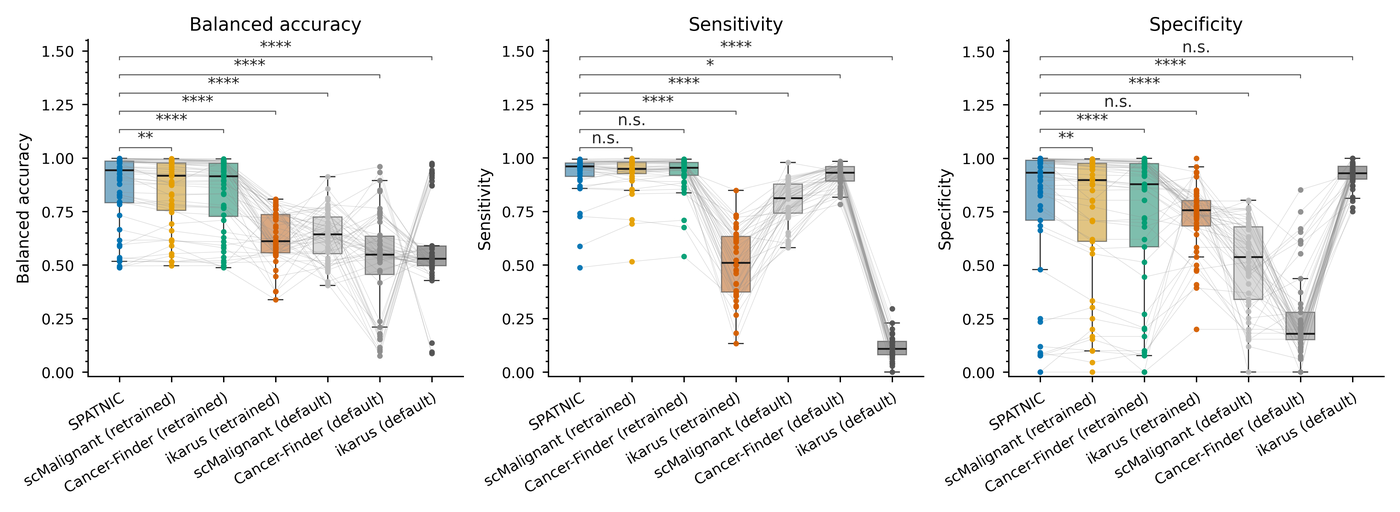

In [ ]:
# Visium tool comparison
Image(str(COMP / "fig_compare_grid.png"))

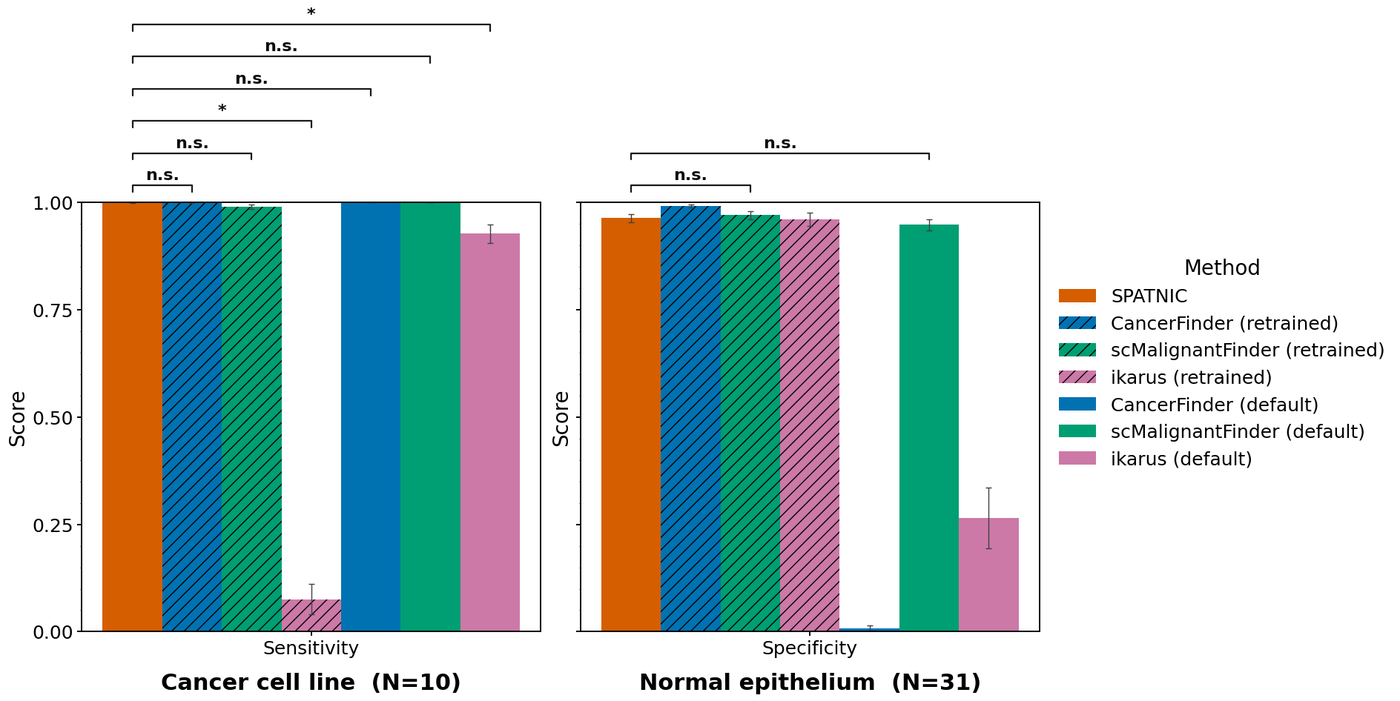

In [ ]:
# scRNA-seq tool comparison
Image(str(COMP / "scrnaseq/fig_benchmark_scrnaseq.png"))